In [13]:
# ══════════════════════════════════════════════════════════════
# DECISION TREE — Student Dropout Prediction
# ══════════════════════════════════════════════════════════════
# Algorithm: Decision Tree Classifier
# Dataset: OULAD — Open University Learning Analytics
# Author: Nikitha (IT22211750)
# ══════════════════════════════════════════════════════════════

# Import data handling libraries

In [14]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.Collecting pandas
     ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
     --------------------------------------- 0.0/11.3 MB 660.6 kB/s eta 0:00:18
     --------------------------------------- 0.1/11.3 MB 653.6 kB/s eta 0:00:18
     --------------------------------------- 0.1/11.3 MB 653.6 kB/s eta 0:00:18
      --------------------------------------- 0.2/11.3 MB 1.0 MB/s eta 0:00:11
     - -------------------------------------- 0.3/11.3 MB 1.3 MB/s eta 0:00:09
     - -------------------------------------- 0.4/11.3 MB 1.3 MB/s eta 0:00:09
     - -------------------------------------- 0.5/11.3 MB 1.3 MB/s eta 0:00:09
     - -------------------------------------- 0.5/11.3 MB 1.4 MB/s eta 0:00:08
     -- ------------------------------------- 0.6/11.3 MB 1.6 MB/s eta 0:00:07
     -- ------------------------------------- 0.7/11.3 MB 1.5 MB/s eta 0:00:07
     -- ------------------------------------- 0.8/11


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [15]:
import pandas as pd

In [16]:
import numpy as np

In [18]:
pip install matplotlib seaborn scikit-learn


     ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
     ---------------------------------------- 0.1/8.1 MB 1.1 MB/s eta 0:00:08
      --------------------------------------- 0.1/8.1 MB 939.4 kB/s eta 0:00:09
     - -------------------------------------- 0.2/8.1 MB 1.2 MB/s eta 0:00:07
     - -------------------------------------- 0.3/8.1 MB 1.4 MB/s eta 0:00:06
     - -------------------------------------- 0.4/8.1 MB 1.3 MB/s eta 0:00:06
     -- ------------------------------------- 0.5/8.1 MB 1.5 MB/s eta 0:00:05
     --- ------------------------------------ 0.6/8.1 MB 1.5 MB/s eta 0:00:05
     --- ------------------------------------ 0.7/8.1 MB 1.6 MB/s eta 0:00:05
     --- ------------------------------------ 0.8/8.1 MB 1.5 MB/s eta 0:00:05
     --- ------------------------------------ 0.8/8.1 MB 1.5 MB/s eta 0:00:06
     ---- ----------------------------------- 0.8/8.1 MB 1.4 MB/s eta 0:00:06
     ---- ----------------------------------- 1.0/8.1 MB 1.5 MB/s et


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [19]:
# Import Decision Tree algorithm
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

In [20]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay
)

In [21]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [23]:
# ══════════════════════════════════════════════════════════════
# LOAD PREPROCESSED DATA
# ══════════════════════════════════════════════════════════════
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("=== Data loaded successfully ===")
print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test  shape: {y_test.shape}")
print()

=== Data loaded successfully ===
X_train shape: (27532, 14)
X_test  shape: (6519, 14)
y_train shape: (27532,)
y_test  shape: (6519,)



In [24]:
print("=== Features used ===")
print(X_train.columns.tolist())
print("Data loaded and ready for Decision Tree!")


=== Features used ===
['highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'total_clicks', 'days_active', 'avg_daily_clicks', 'avg_score', 'total_score', 'submission_count', 'min_score', 'max_score', 'withdrew_early']
Data loaded and ready for Decision Tree!


In [25]:
# ══════════════════════════════════════════════════════════════
# TRAIN DECISION TREE MODEL
# ══════════════════════════════════════════════════════════════
print("Training Decision Tree model...\n")

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!\n")
print(f"Max depth:        {dt_model.max_depth}")
print(f"Features per split: {dt_model.n_features_in_}")
print(f"Classes predicted:  {dt_model.classes_}")


Training Decision Tree model...

Decision Tree model trained successfully!

Max depth:        10
Features per split: 14
Classes predicted:  [0 1]


In [26]:
# ══════════════════════════════════════════════════════════════
# PREDICTIONS AND EVALUATION METRICS
# ══════════════════════════════════════════════════════════════
y_pred = dt_model.predict(X_test)
y_pred_proba = dt_model.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_proba)

print("\n=== MODEL EVALUATION RESULTS ===")
print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1 Score:  {f1*100:.2f}%")
print(f"ROC-AUC:   {roc_auc*100:.2f}%\n")

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Non-Dropout (0)', 'Dropout (1)']))



=== MODEL EVALUATION RESULTS ===
Accuracy:  88.39%
Precision: 90.74%
Recall:    86.87%
F1 Score:  88.76%
ROC-AUC:   93.83%

=== CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

Non-Dropout (0)       0.86      0.90      0.88      3077
    Dropout (1)       0.91      0.87      0.89      3442

       accuracy                           0.88      6519
      macro avg       0.88      0.88      0.88      6519
   weighted avg       0.88      0.88      0.88      6519



In [27]:
# ══════════════════════════════════════════════════════════════
# OVERFITTING CHECK
# ══════════════════════════════════════════════════════════════
train_accuracy = dt_model.score(X_train, y_train)
test_accuracy  = dt_model.score(X_test, y_test)
gap = (train_accuracy - test_accuracy) * 100

print(f"\nTrain accuracy: {train_accuracy*100:.2f}%")
print(f"Test accuracy:  {test_accuracy*100:.2f}%")
print(f"Gap:            {gap:.2f}%")
if gap < 5:
    print("No overfitting")
elif gap < 10:
    print("Mild overfitting")
else:
    print("Overfitting detected")


Train accuracy: 91.73%
Test accuracy:  88.39%
Gap:            3.35%
No overfitting


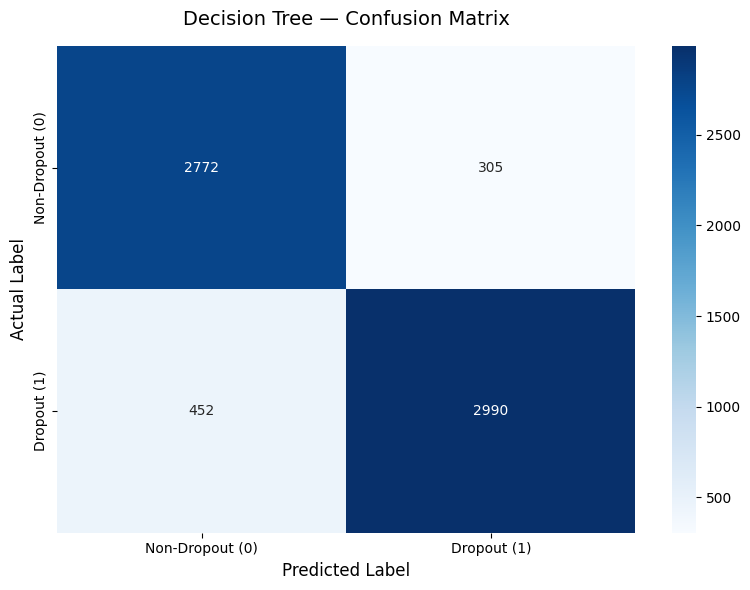


True Negatives  (correctly predicted Non-Dropout): 2772
False Positives (predicted Dropout, actually Not): 305
False Negatives (predicted Not, actually Dropout): 452
True Positives  (correctly predicted Dropout):     2990
Total correct predictions:   5762
Total incorrect predictions: 757
Confusion matrix chart saved to report folder!


In [28]:
# ══════════════════════════════════════════════════════════════
# CONFUSION MATRIX
# ══════════════════════════════════════════════════════════════
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Dropout (0)', 'Dropout (1)'],
    yticklabels=['Non-Dropout (0)', 'Dropout (1)']
)
plt.title('Decision Tree — Confusion Matrix', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.savefig('../report/04_dt_confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly predicted Non-Dropout): {tn}")
print(f"False Positives (predicted Dropout, actually Not): {fp}")
print(f"False Negatives (predicted Not, actually Dropout): {fn}")
print(f"True Positives  (correctly predicted Dropout):     {tp}")
print(f"Total correct predictions:   {tn+tp}")
print(f"Total incorrect predictions: {fp+fn}")
print("Confusion matrix chart saved to report folder!")

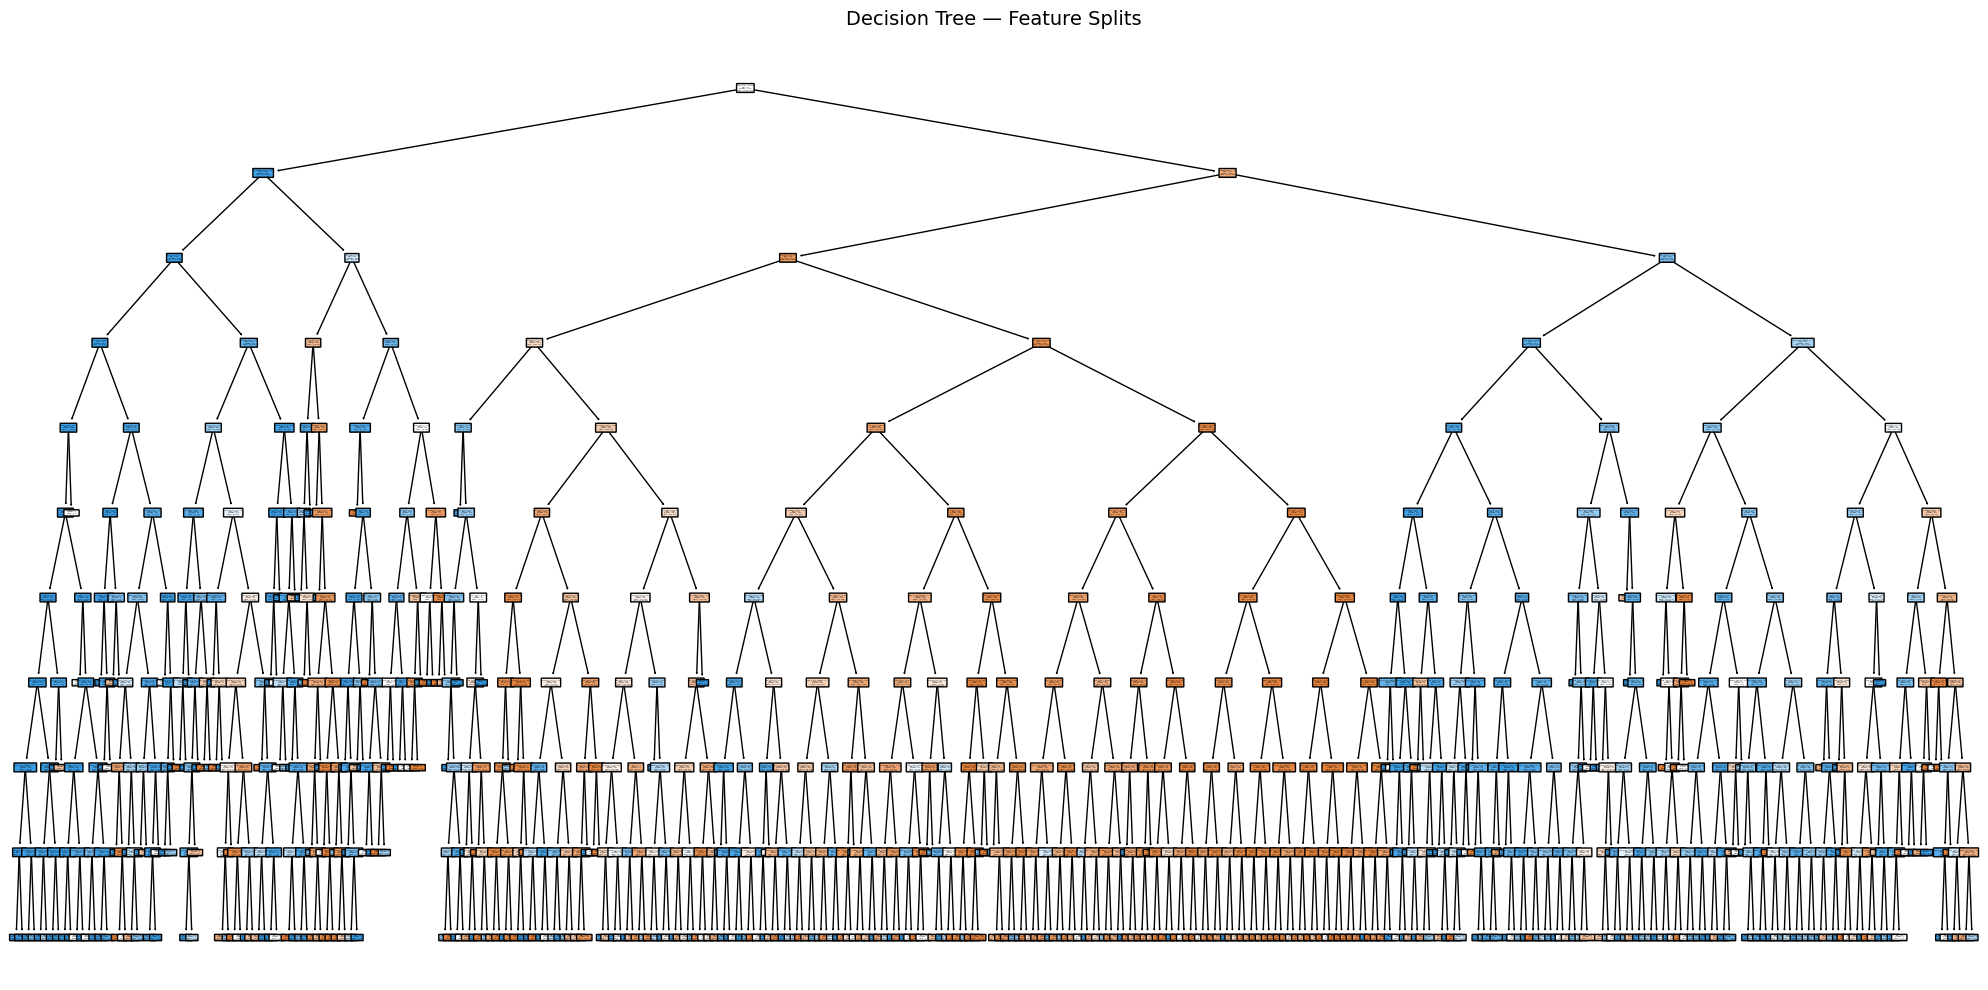


=== Decision Tree Rules ===
|--- total_score <= 269.11
|   |--- submission_count <= 4.04
|   |   |--- days_active <= 51.50
|   |   |   |--- total_score <= 220.50
|   |   |   |   |--- total_clicks <= 3203.50
|   |   |   |   |   |--- total_score <= 176.50
|   |   |   |   |   |   |--- age_band <= 1.50
|   |   |   |   |   |   |   |--- days_active <= 28.49
|   |   |   |   |   |   |   |   |--- num_of_prev_attempts <= 2.50
|   |   |   |   |   |   |   |   |   |--- imd_band <= 7.50
|   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |   |--- imd_band >  7.50
|   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |--- num_of_prev_attempts >  2.50
|   |   |   |   |   |   |   |   |   |--- avg_daily_clicks <= 3.61
|   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |   |--- avg_daily_clicks >  3.61
|   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- days_active >  2

In [29]:
# ══════════════════════════════════════════════════════════════
# FEATURE IMPORTANCE / TREE VISUALIZATION
# ══════════════════════════════════════════════════════════════
# Plot Decision Tree
plt.figure(figsize=(20,10))
plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=['Non-Dropout', 'Dropout'],
    filled=True,
    rounded=True
)
plt.title('Decision Tree — Feature Splits', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../report/05_dt_tree.png', dpi=150)
plt.show()

# Textual rules
tree_rules = export_text(dt_model, feature_names=list(X_train.columns))
print("\n=== Decision Tree Rules ===")
print(tree_rules)
print("Decision tree chart and rules saved to report folder!")

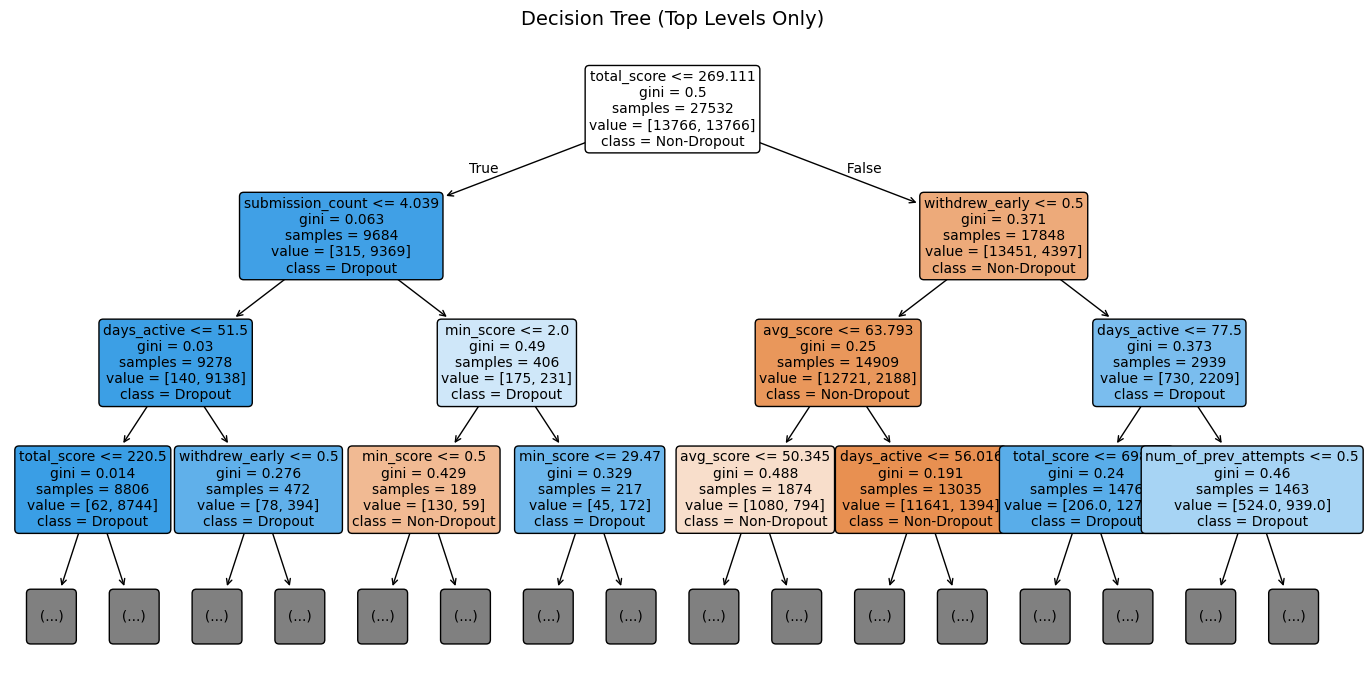


=== Simplified Decision Tree Rules ===
|--- total_score <= 269.11
|   |--- submission_count <= 4.04
|   |   |--- days_active <= 51.50
|   |   |   |--- total_score <= 220.50
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- total_score >  220.50
|   |   |   |   |--- truncated branch of depth 7
|   |   |--- days_active >  51.50
|   |   |   |--- withdrew_early <= 0.50
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- withdrew_early >  0.50
|   |   |   |   |--- truncated branch of depth 7
|   |--- submission_count >  4.04
|   |   |--- min_score <= 2.00
|   |   |   |--- min_score <= 0.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- min_score >  0.50
|   |   |   |   |--- truncated branch of depth 7
|   |   |--- min_score >  2.00
|   |   |   |--- min_score <= 29.47
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- min_score >  29.47
|   |   |   |   |--- truncated branch of depth 5
|--- total_score >  269.11
|   |--- withdre

In [30]:
from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt

# Limit tree depth for visualization
plt.figure(figsize=(14, 7))

plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=['Non-Dropout', 'Dropout'],
    filled=True,
    rounded=True,
    max_depth=3,          # 👈 KEY: show only top levels
    fontsize=10
)

plt.title('Decision Tree (Top Levels Only)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../report/05_dt_tree_clean.png', dpi=150)
plt.show()


# ===== Cleaner Text Rules (Limited Depth) =====
tree_rules = export_text(
    dt_model,
    feature_names=list(X_train.columns),
    max_depth=3           # 👈 match visualization depth
)

print("\n=== Simplified Decision Tree Rules ===")
print(tree_rules)